In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import cmocean
import pandas as pd

import ArcTools as Atools

# Load data

### ISAS vertical levels

In [2]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data

### UDASH
/home/aprigent/Documents/Projects/Analysis_obs/load_interp_udash_data.ipynb

In [3]:
udash_path = '/data0/user/aprigent/UDASH/'
udash_list_psal = glob.glob(udash_path + '*ISAS_TEMP_no_argo_no_whoi_no_nabo_no_ices_no_wod13.nc')

### ITP
/home/aprigent/Documents/Projects/Analysis_obs/load_interp_itp_data.ipynb

In [4]:
itp_path = '/data0/user/aprigent/ITP/'
itp_list_psal = glob.glob(itp_path + '*ISAS_TEMP.nc')

### ARGO
/home/aprigent/Documents/Projects/Analysis_obs/load_interp_argo_data.ipynb

In [5]:
argo_path = '/data0/user/aprigent/ARGO/Arctic/'
argo_list_psal = glob.glob(argo_path + '*ISAS_TEMP.nc')

### NABOS CTDs
/home/aprigent/Documents/Projects/Analysis_obs/load_interp_NABOS_CTD.ipynb

In [6]:
DIR_NABOS = '/data0/user/aprigent/NABOS/CTD/'
nabos_list_psal = glob.glob(DIR_NABOS + '*ISAS_TEMP.nc')

### BGEP CTD data
Projects/Analysis_obs/load_interp_BGEP_CTD.ipynb

In [7]:
bgep_path = '/data0/user/aprigent/BGEP/'
bgep_list_psal = glob.glob(bgep_path + '*_ctd_TS_CTD_ISAS_TEMP.nc')

# ICES
Projects/Analysis_obs/load_interp_ICES_data.ipynb

In [8]:
ices_path = '/data0/user/aprigent/ICES/'
ices_list_psal = glob.glob(ices_path + 'ICES_ISAS_TEMP.nc')


# CORA
Projects/Analysis_obs/load_interp_CORA_data.ipynb

In [9]:
cora_path = '/data0/user/aprigent/CORA/processed/'
cora_list_psal = glob.glob(cora_path + '*_CT_ISAS_TEMP.nc')

# WOD23
Projects/Analysis_obs/load_interp_WOD23_data.ipynb

In [10]:
wod_path = '/data0/user/aprigent/WOD/processed/'
wod_list_psal = glob.glob(wod_path + '*_ISAS_TEMP.nc')

# Concatenate function

In [11]:
ds_udash_psal = Atools.create_merged_dataset_temp(udash_list_psal,'UDASH','temp')
ds_itp_psal = Atools.create_merged_dataset_temp(itp_list_psal,'ITP','temp')
ds_argo_psal = Atools.create_merged_dataset_temp(argo_list_psal,'ARGO','temp')
ds_nabos_psal = Atools.create_merged_dataset_temp(nabos_list_psal,'NABOS_ctd','temp')
ds_bgep_psal = Atools.create_merged_dataset_temp(bgep_list_psal,'BGEP_ctd','temp')
ds_ices_psal = Atools.create_merged_dataset_temp(ices_list_psal,'ICES','temp')
ds_cora_psal = Atools.create_merged_dataset_temp(cora_list_psal,'CORA','temp')
ds_wod_psal = Atools.create_merged_dataset_temp(wod_list_psal,'WOD','temp')

In [12]:
import datetime
print(datetime.datetime.fromordinal(int(ds_wod_psal.time.min().values)))
print(datetime.datetime.fromordinal(int(ds_wod_psal.time.max().values)))

1980-01-01 00:00:00
2024-10-18 00:00:00


In [13]:
df_profiles_tmp = xr.concat([ds_argo_psal,ds_itp_psal,
                         ds_nabos_psal,ds_bgep_psal,ds_udash_psal,
                         ds_ices_psal,ds_wod_psal,ds_cora_psal
                         ],dim='profile') 

df_profiles_tmp['profile'] = np.arange(0,df_profiles_tmp.longitude.shape[0],1)

df_profiles_tmp = df_profiles_tmp.where(df_profiles_tmp.nb_depth>2,drop=True)   
df_profiles_tmp

<xarray.Dataset>
Dimensions:          (profile: 487709, depth: 187)
Coordinates:
  * profile          (profile) int64 0 1 2 3 4 ... 490251 490252 490253 490254
  * depth            (depth) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
Data variables:
    longitude        (profile) float64 -29.8 -31.12 -31.78 ... 20.8 20.28 20.07
    latitude         (profile) float64 65.08 65.06 65.09 ... 70.4 70.17 69.95
    time             (profile) float64 7.36e+05 7.36e+05 ... 7.237e+05 7.237e+05
    source           (profile) object 'ARGO' 'ARGO' 'ARGO' ... 'CORA' 'CORA'
    dataset_index    (profile) float64 119.0 120.0 121.0 ... 2.314e+05 2.314e+05
    is_duplicate     (profile) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    temperature      (profile, depth) float64 nan 5.962 5.959 ... nan nan nan
    sum_temperature  (profile) float64 3.318e+03 3.823e+03 ... 1.381e+03 844.3
    sum_depth        (profile) float64 5.551e+05 5.564e+05 ... 2.409e+04
    nb_depth         (profile) float64 750.0 750.0 750.0 46.0 ... 5.0 5.0 5.0
Attributes:
    title:        ARGO temperature profiles
    source:       ARGO
    featureType:  profile
    Comments:     ARGO temperature profiles interpolated on ISAS vertical lev...

In [14]:
def build_key(ds):
    # safer precision: avoid too coarse rounding
    time = np.char.mod('%.5f', ds.time.values)
    lat  = np.char.mod('%.5f', ds.latitude.values)
    lon  = np.char.mod('%.5f', ds.longitude.values)
    

    key = np.char.add(time, "_")
    key = np.char.add(key, lat)
    key = np.char.add(key, "_")
    key = np.char.add(key, lon)

    return key

def drop_duplicate_profiles(ds):
    key = build_key(ds)
    _, unique_idx = np.unique(key, return_index=True)
    n_before = ds.profile.size
    ds_deduped = ds.isel(profile=unique_idx)
    n_dropped = n_before - ds_deduped.profile.size
    print(f"Dropped {n_dropped} duplicate profiles, {ds_deduped.profile.size} remaining")
    return ds_deduped

df_profiles = drop_duplicate_profiles(df_profiles_tmp)

Dropped 143764 duplicate profiles, 343945 remaining


# Keep only profiles with more than 2 levels

In [15]:
df_profiles.profile.shape[0]

343945

In [16]:

df_profiles = df_profiles.where(df_profiles.nb_depth>2,drop=True)
df_profiles.profile.shape[0]

343945

In [17]:
ds_profiles_unique_UDASH_old = df_profiles.where(
    df_profiles["source"]=='UDASH',drop=True)

ds_profiles_unique_ARGO_old = df_profiles.where(
    df_profiles["source"]=='ARGO',drop=True)

ds_profiles_unique_ITP_old = df_profiles.where(
    df_profiles["source"]=='ITP',drop=True)

ds_profiles_unique_NABOS_old = df_profiles.where(
    df_profiles["source"]=='NABOS_ctd',drop=True)

ds_profiles_unique_BGEP_old = df_profiles.where(
    df_profiles["source"]=='BGEP_ctd',drop=True)

ds_profiles_unique_ICES_old = df_profiles.where(
    df_profiles["source"]=='ICES',drop=True)

ds_profiles_unique_WOD_old = df_profiles.where(
    df_profiles["source"]=='WOD',drop=True)

ds_profiles_unique_CORA_old = df_profiles.where(
    df_profiles["source"]=='CORA',drop=True)

In [18]:
lon_all = np.array(df_profiles.longitude)
lat_all = np.array(df_profiles.latitude)
time_all = np.array(df_profiles.time)
psal_all = np.array(df_profiles.temperature)
source_all = np.array(df_profiles.source)
psal_sum_all = np.array(df_profiles.sum_temperature)
print(source_all.shape)

(343945,)


# Define function to find duplicates in the datasets

In [19]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
import gsw

NO_INTERNAL_DUPLICATES = {'ITP', 'ARGO','BGEP_ctd','NABOS_ctd'}

def find_duplicates_new3(lon, lat, time, profiles, source,
                        time_thresh_days=1, 
                        lon_thresh=0.05, lat_thresh=0.02, 
                        dist_thresh_km=2):
    """
    Detect potential duplicate profiles based on time, location, and data source.

    A pair of profiles is considered a duplicate if:
    - They occur within `time_thresh_days`
    - Their longitude and latitude differences fall within coarse thresholds
    - Their geodesic distance is below `dist_thresh_km`
    - They originate from different sources (cross-source duplicates)
    - Except when both sources are known to contain no internal duplicates

    Parameters
    ----------
    lon, lat : array-like
        Longitude and latitude of profiles.
    time : array-like
        Profile time (numeric format; fractional days allowed).
    profiles : array-like
        Profile identifiers (not used directly here but kept for compatibility).
    source : array-like
        Source dataset identifier for each profile.
    time_thresh_days : float
        Maximum time difference allowed for duplicates (in days).
    lon_thresh, lat_thresh : float
        Initial bounding box thresholds to pre-filter candidates.
    dist_thresh_km : float
        Maximum great-circle distance allowed for duplicates.

    Returns
    -------
    original_duplicate_mask : ndarray of bool
        Boolean mask indicating which profiles are duplicates.
    original_duplicate_pairs : list of tuple
        List of index pairs representing duplicate profile pairs.
    """

    # Number of profiles
    n = len(lon)

    # Boolean mask marking duplicate profiles
    duplicate_mask = np.zeros(n, dtype=bool)

    # List storing index pairs of duplicates
    duplicate_pairs = []

    # Convert times to integer days for coarse comparison
    time_days = np.floor(time)

    # Sort profiles by time to allow early stopping in the search
    order = np.argsort(time_days, kind='stable')

    # Reorder arrays consistently
    lon       = lon[order]
    lat       = lat[order]
    time_days = time_days[order]
    source    = source[order]

    # Reduce floating-point noise in coordinates
    lon = np.round(lon, 4)
    lat = np.round(lat, 4)

    # Main loop over profiles
    for i in range(n):

        # Progress indicator for large datasets
        if i % 10000 == 0:
            print("Processing", i)

        # Candidate indices after the current profile
        j = np.arange(i + 1, n)
        if len(j) == 0:
            continue

        # Compute time difference relative to profile i
        time_diff = np.abs(time_days[j] - time_days[i])

        # Stop searching once time difference exceeds threshold
        exceeds = np.where(time_diff > time_thresh_days)[0]
        if len(exceeds) > 0:
            j = j[:exceeds[0]]

        if len(j) == 0:
            continue

        # Coarse geographic filtering (bounding box)
        lon_ok = np.abs(lon[j] - lon[i]) <= lon_thresh
        lat_ok = np.abs(lat[j] - lat[i]) <= lat_thresh

        # Only consider cross-source duplicates
        source_ok = source[j] != source[i]

        # Prevent pairing two sources known to have no internal duplicates
        both_clean = (
            np.isin(source[j], list(NO_INTERNAL_DUPLICATES)) &
            (source[i] in NO_INTERNAL_DUPLICATES)
        )

        source_ok = source_ok & ~both_clean

        # Combine spatial and source filters
        candidates = j[lon_ok & lat_ok & source_ok]
        if len(candidates) == 0:
            continue

        # Compute accurate geodesic distances (km) for candidates
        d_km = np.array([
            gsw.distance(np.array([[lon[i], lon[c]]]),
                         np.array([[lat[i], lat[c]]])) / 1000.0
            for c in candidates
        ]).flatten()

        candidates = np.array(candidates)

        # Final duplicate check using distance threshold
        duplicates = candidates[d_km <= dist_thresh_km]

        # Mark duplicates and store index pairs
        if len(duplicates) > 0:
            duplicate_mask[i] = True
            duplicate_mask[duplicates] = True
            duplicate_pairs.extend([(i, dup) for dup in duplicates])

    # Convert mask back to original ordering
    original_duplicate_mask = np.zeros(n, dtype=bool)
    original_duplicate_mask[order[duplicate_mask]] = True

    # Convert duplicate pairs back to original indexing
    original_duplicate_pairs = [(order[i], order[j]) for i, j in duplicate_pairs]

    return original_duplicate_mask, original_duplicate_pairs




In [20]:
%%time
duplicate_mask, duplicate_pairs = find_duplicates_new3(
    lon_all, lat_all, time_all, psal_all, source_all
)
print(f"Raw duplicate pairs found: {len(duplicate_pairs)}")


Processing 0
Processing 10000
Processing 20000
Processing 30000
Processing 40000
Processing 50000
Processing 60000
Processing 70000
Processing 80000
Processing 90000
Processing 100000
Processing 110000
Processing 120000
Processing 130000
Processing 140000
Processing 150000
Processing 160000
Processing 170000
Processing 180000
Processing 190000
Processing 200000
Processing 210000
Processing 220000
Processing 230000
Processing 240000
Processing 250000
Processing 260000
Processing 270000
Processing 280000
Processing 290000
Processing 300000
Processing 310000
Processing 320000
Processing 330000
Processing 340000
Raw duplicate pairs found: 36671
CPU times: user 3min 54s, sys: 208 ms, total: 3min 55s
Wall time: 3min 54s


In [21]:
n_profiles       = len(psal_all)
finite_counts    = np.sum(np.isfinite(psal_all), axis=1)   # original order

SOURCE_PRIORITY = {
    
    "ARGO":      0,
    "ITP":       1,
    "NABOS_ctd": 2,
    "BGEP_ctd":  3,
    "UDASH":     4,
    "ICES":      5,
    "WOD":       6,
    "CORA":      7,
}

def resolve_duplicates_pairwise(duplicate_pairs, source, finite_counts, n_profiles):
    """
    Resolve duplicates pair by pair
    For each pair (i, j), discard the lower priority profile.
    """
    discard_mask = np.zeros(n_profiles, dtype=bool)

    def score(idx):
        return (SOURCE_PRIORITY.get(source[idx], 999), -finite_counts[idx])

    for i, j in duplicate_pairs:
        # If both already discarded, skip
        if discard_mask[i] and discard_mask[j]:
            continue
        # Keep the better one, discard the worse
        if score(i) <= score(j):  # i is better or equal
            discard_mask[j] = True
        else:
            discard_mask[i] = True

    return discard_mask

discard_mask = resolve_duplicates_pairwise(
    duplicate_pairs, source_all, finite_counts, n_profiles
)

# ── APPLY TO DATASET ───────────────────────────────────────────────────────

df_profiles["is_duplicate"]  = xr.DataArray(discard_mask, dims=["profile"])
ds_unique = df_profiles.where(~df_profiles["is_duplicate"], drop=True)

print(f"\nTotal profiles  : {n_profiles}")
print(f"Marked discard  : {discard_mask.sum()}")
print(f"Kept (unique)   : {(~discard_mask).sum()}")


Total profiles  : 343945
Marked discard  : 23728
Kept (unique)   : 320217


In [22]:
import pandas as pd
import numpy as np

def create_duplicate_audit_table(
    duplicate_pairs,
    source,
    finite_counts,
    discard_mask,
    df_profiles
):

    rows = []

    lon = df_profiles["longitude"].values
    lat = df_profiles["latitude"].values
    time = df_profiles["time"].values

    for i, j in duplicate_pairs:

        row = {
            "profile_i": i,
            "profile_j": j,

            "time_i": time[i],
            "time_j": time[j],

            "lon_i": lon[i],
            "lat_i": lat[i],

            "lon_j": lon[j],
            "lat_j": lat[j],

            "source_i": source[i],
            "source_j": source[j],

            "finite_i": finite_counts[i],
            "finite_j": finite_counts[j],

            "priority_i": SOURCE_PRIORITY.get(source[i], 999),
            "priority_j": SOURCE_PRIORITY.get(source[j], 999),

            "discard_i": discard_mask[i],
            "discard_j": discard_mask[j],
        }

        # determine which profile was kept
        if discard_mask[i] and not discard_mask[j]:
            row["kept_profile"] = j
            row["discarded_profile"] = i
        elif discard_mask[j] and not discard_mask[i]:
            row["kept_profile"] = i
            row["discarded_profile"] = j
        else:
            row["kept_profile"] = None
            row["discarded_profile"] = None

        # optional QC metrics
        row["time_diff_hours"] = abs(time[i] - time[j])

        rows.append(row)

    audit_df = pd.DataFrame(rows)

    return audit_df

In [23]:
audit_duplicates = create_duplicate_audit_table(
    duplicate_pairs,
    df_profiles.source.values,
    finite_counts,
    discard_mask,
    df_profiles
)

In [24]:
audit_duplicates.to_csv(
    "duplicate_audit_temp_dist_time_new_07052026.csv",
    index=False,
    float_format="%.4f",    # lon/lat readable, not 1.23456789e+01
    sep=";",                # semicolon → Excel (French locale) opens cleanly
    encoding="utf-8-sig",   # BOM header → Excel detects UTF-8 without garbling
)

In [25]:
ds_profiles_unique_UDASH = ds_unique.where(ds_unique["source"]=='UDASH',drop=True)
ds_profiles_unique_ITP = ds_unique.where(ds_unique["source"]=='ITP',drop=True)
ds_profiles_unique_ARGO = ds_unique.where(ds_unique["source"]=='ARGO',drop=True)
ds_profiles_unique_NABOS = ds_unique.where(ds_unique["source"]=='NABOS_ctd',drop=True)
ds_profiles_unique_BGEP = ds_unique.where(ds_unique["source"]=='BGEP_ctd',drop=True)
ds_profiles_unique_ICES = ds_unique.where(ds_unique["source"]=='ICES',drop=True)
ds_profiles_unique_CORA = ds_unique.where(ds_unique["source"]=='CORA',drop=True)
ds_profiles_unique_WOD = ds_unique.where(ds_unique["source"]=='WOD',drop=True)

In [26]:
print(((ds_profiles_unique_ITP.temperature.shape[0]-
  ds_profiles_unique_ITP_old.temperature.shape[0])/
 ds_profiles_unique_ITP_old.temperature.shape[0])*100)

print(((ds_profiles_unique_ARGO.temperature.shape[0]-
  ds_profiles_unique_ARGO_old.temperature.shape[0])/
 ds_profiles_unique_ARGO_old.temperature.shape[0])*100)

print(((ds_profiles_unique_NABOS.temperature.shape[0]-
  ds_profiles_unique_NABOS_old.temperature.shape[0])/
 ds_profiles_unique_NABOS_old.temperature.shape[0])*100)

print(((ds_profiles_unique_BGEP.temperature.shape[0]-
  ds_profiles_unique_BGEP_old.temperature.shape[0])/
 ds_profiles_unique_BGEP_old.temperature.shape[0])*100)

print(((ds_profiles_unique_UDASH.temperature.shape[0]-
  ds_profiles_unique_UDASH_old.temperature.shape[0])/
 ds_profiles_unique_UDASH_old.temperature.shape[0])*100)

print(((ds_profiles_unique_ICES.temperature.shape[0]-
  ds_profiles_unique_ICES_old.temperature.shape[0])/
 ds_profiles_unique_ICES_old.temperature.shape[0])*100)

print(((ds_profiles_unique_WOD.temperature.shape[0]-
  ds_profiles_unique_WOD_old.temperature.shape[0])/
 ds_profiles_unique_WOD_old.temperature.shape[0])*100)

print(((ds_profiles_unique_CORA.temperature.shape[0]-
  ds_profiles_unique_CORA_old.temperature.shape[0])/
 ds_profiles_unique_CORA_old.temperature.shape[0])*100)


0.0
0.0
0.0
0.0
-4.26731078904992
-0.869431912750208
-4.650056950756947
-30.577309811487336


In [27]:
ds_profiles_unique_UDASH['profile'] = np.arange(0,ds_profiles_unique_UDASH.longitude.shape[0],1)
ds_profiles_unique_ITP['profile'] = np.arange(0,ds_profiles_unique_ITP.longitude.shape[0],1)
ds_profiles_unique_ARGO['profile'] = np.arange(0,ds_profiles_unique_ARGO.longitude.shape[0],1)
ds_profiles_unique_NABOS['profile'] = np.arange(0,ds_profiles_unique_NABOS.longitude.shape[0],1)
ds_profiles_unique_BGEP['profile'] = np.arange(0,ds_profiles_unique_BGEP.longitude.shape[0],1)
ds_profiles_unique_ICES['profile'] = np.arange(0,ds_profiles_unique_ICES.longitude.shape[0],1)
ds_profiles_unique_CORA['profile'] = np.arange(0,ds_profiles_unique_CORA.longitude.shape[0],1)
ds_profiles_unique_WOD['profile'] = np.arange(0,ds_profiles_unique_WOD.longitude.shape[0],1)


In [28]:
ds_profiles_unique_UDASH.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_UDASH_ISAS_TEMP_new.nc')
ds_profiles_unique_ITP.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ITP_ISAS_TEMP_new.nc')
ds_profiles_unique_ARGO.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ARGO_ISAS_TEMP_new.nc')
ds_profiles_unique_NABOS.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_NABOS_ISAS_TEMP_new.nc')
ds_profiles_unique_BGEP.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_BGEP_ISAS_TEMP_new.nc')
ds_profiles_unique_ICES.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ICES_ISAS_TEMP_new.nc')
ds_profiles_unique_CORA.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_CORA_ISAS_TEMP_new.nc')
ds_profiles_unique_WOD.to_netcdf('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_WOD_ISAS_TEMP_new.nc')

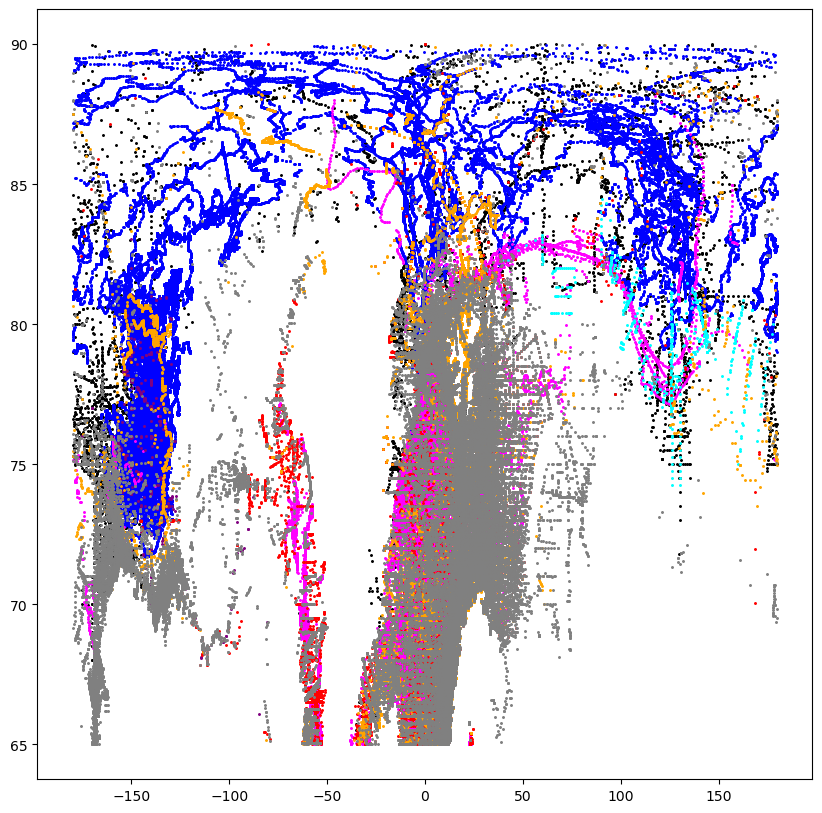

In [29]:
f,ax = plt.subplots(1,1,figsize=[10,10])

# Atools.plot_arctic_ax_map_new(ax[0])
ax.scatter(ds_profiles_unique_UDASH.longitude,
           ds_profiles_unique_UDASH.latitude,
           marker='.',s=5,color='black',label='All')


# Atools.plot_arctic_ax_map_new(ax[1])
ax.scatter(ds_profiles_unique_ITP.longitude,
           ds_profiles_unique_ITP.latitude,
           marker='.',s=5,color='blue',label='All')


# Atools.plot_arctic_ax_map_new(ax[2])
ax.scatter(ds_profiles_unique_ARGO.longitude,
           ds_profiles_unique_ARGO.latitude,
           marker='.',s=5,color='magenta',label='All')


# Atools.plot_arctic_ax_map_new(ax[3])
ax.scatter(ds_profiles_unique_NABOS.longitude,
           ds_profiles_unique_NABOS.latitude,
           marker='.',s=5,color='cyan',label='All')


# Atools.plot_arctic_ax_map_new(ax[4])
plt.scatter(ds_profiles_unique_BGEP.longitude,
           ds_profiles_unique_BGEP.latitude,
           marker='.',s=5,color='purple',label='All')


# Atools.plot_arctic_ax_map_new(ax[5])
ax.scatter(ds_profiles_unique_ICES.longitude,
           ds_profiles_unique_ICES.latitude,
           marker='.',s=5,color='red',label='All')


# Atools.plot_arctic_ax_map_new(ax[6])
ax.scatter(ds_profiles_unique_CORA.longitude,
           ds_profiles_unique_CORA.latitude,
           marker='.',s=5,color='orange',label='All')



# Atools.plot_arctic_ax_map_new(ax[7])
ax.scatter(ds_profiles_unique_WOD.longitude,
           ds_profiles_unique_WOD.latitude,
           marker='.',s=5,color='grey',label='All')



# ax.set_ylim([70,75])
####################################################################################

#plt.savefig('/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_data_distributions_ALL.png',bbox_inches='tight',dpi=300)